# 07 - Validacion y caso de negocio (Fase 10)

Se compara la utilidad neta esperada bajo las tasas optimizadas (escenario "Equilibrio" de la Fase 9) contra la utilidad neta esperada bajo las tasas históricas efectivamente usadas por LendingClub, evaluando **ambas con la misma fórmula de Phillips** (para que la comparación sea consistente: mismo `PD_i`, `LGD_i`, misma forma funcional, solo cambia la tasa y la `p` que le corresponde según el modelo de demanda).

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.aggregation import add_risk_percentile_accepted, build_demand_feature_frame  # noqa: E402
from src.optimization import (  # noqa: E402
    MONTHS_PER_YEAR,
    add_objective_terms,
    build_optimization_table,
    solve_pricing,
)
from src.risk_model import FUNDING_COST_BASE  # noqa: E402

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

accepted_with_risk = pd.read_csv(PROCESSED_DIR / "accepted_with_risk.csv.gz", low_memory=False)
accepted_with_risk = add_risk_percentile_accepted(accepted_with_risk)
demand_pipeline = joblib.load(MODELS_DIR / "demand_model.joblib")
subgrade_params = pd.read_csv(PROCESSED_DIR / "subgrade_params.csv")
subgrade_elasticity = pd.read_csv(PROCESSED_DIR / "subgrade_elasticity.csv")
frontier = pd.read_csv(PROCESSED_DIR / "efficient_frontier.csv")
rates_by_scenario = pd.read_csv(PROCESSED_DIR / "efficient_frontier_rates.csv", index_col=0)

print(f"accepted_with_risk: {accepted_with_risk.shape}")

accepted_with_risk: (149996, 158)


In [2]:
X_historical = build_demand_feature_frame(accepted_with_risk, tasa=accepted_with_risk["int_rate"])
accepted_with_risk["p_historico"] = demand_pipeline.predict_proba(X_historical)[:, 1]

historical_by_subgrade = accepted_with_risk.groupby("sub_grade").agg(
    tasa_historica=("int_rate", "mean"), p_historico=("p_historico", "mean")
)

historical = subgrade_params.merge(historical_by_subgrade, on="sub_grade")
historical["n_years"] = historical["n_i"] / MONTHS_PER_YEAR
historical["profit_term"] = historical["P_i"] * historical["p_historico"] * (
    historical["n_years"] * (historical["tasa_historica"] / 100 - FUNDING_COST_BASE)
    - historical["PD"] * historical["LGD"]
)
historical["volume_term"] = historical["P_i"] * historical["p_historico"]

total_profit_historico = historical["profit_term"].sum()
total_volume_historico = historical["volume_term"].sum()

print(f"Utilidad neta esperada -- tasas históricas: ${total_profit_historico:,.0f}")
print(f"Volumen esperado -- tasas históricas: ${total_volume_historico:,.0f}")

Utilidad neta esperada -- tasas históricas: $151,269
Volumen esperado -- tasas históricas: $400,669


## Punto de comparación correcto: "Punto B" de Phillips (Figura 2)

El escenario "Equilibrio" de la Fase 9 se eligió por su posición en la frontera de 5 puntos, no porque estuviera diseñado para superar específicamente al pricing histórico. Para una comparación rigurosa, Phillips (2013) define el **Punto B**: la utilidad máxima que se puede alcanzar **manteniendo el volumen actual** (Punto A = pricing histórico). Se resuelve el optimizador una vez más con `min_volume` fijado exactamente al volumen esperado bajo tasas históricas -- este sí es, por construcción, el punto que corresponde comparar contra el histórico.

In [3]:
table = build_optimization_table(subgrade_params, subgrade_elasticity)
table = add_objective_terms(table, funding_cost=FUNDING_COST_BASE)

point_b = solve_pricing(table, objective="profitability", min_volume=total_volume_historico)

print(f"Punto B -- status: {point_b['status']}")
print(f"Punto B -- volumen: ${point_b['total_volume']:,.0f} (histórico: ${total_volume_historico:,.0f})")
print(f"Punto B -- utilidad: ${point_b['total_profit']:,.0f} (histórico: ${total_profit_historico:,.0f})")

Punto B -- status: Optimal
Punto B -- volumen: $400,671 (histórico: $400,669)
Punto B -- utilidad: $152,518 (histórico: $151,269)


In [4]:
comparison = pd.DataFrame(
    {
        "Tasas históricas (Punto A)": [total_volume_historico, total_profit_historico],
        "Tasas optimizadas (Punto B)": [point_b["total_volume"], point_b["total_profit"]],
    },
    index=["Volumen esperado ($)", "Utilidad neta esperada ($)"],
)
comparison["Upside ($)"] = (
    comparison["Tasas optimizadas (Punto B)"] - comparison["Tasas históricas (Punto A)"]
)
comparison["Upside (%)"] = (
    comparison["Upside ($)"] / comparison["Tasas históricas (Punto A)"].abs() * 100
)
comparison

,Tasas históricas (Punto A),Tasas optimizadas (Punto B),Upside ($),Upside (%)
Volumen esperado ($),400669.166957,400671.172024,2.005067,0.000500
Utilidad neta esperada ($),151268.716155,152517.689719,1248.973564,0.825665


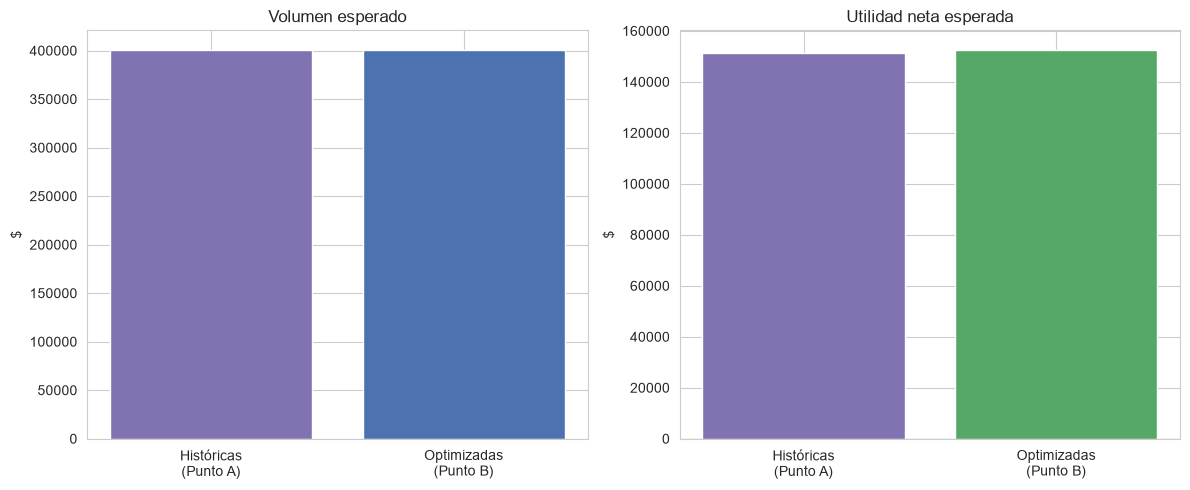

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    ["Históricas\n(Punto A)", "Optimizadas\n(Punto B)"],
    [total_volume_historico, point_b["total_volume"]],
    color=["#8172B2", "#4C72B0"],
)
axes[0].set_title("Volumen esperado")
axes[0].set_ylabel("$")

axes[1].bar(
    ["Históricas\n(Punto A)", "Optimizadas\n(Punto B)"],
    [total_profit_historico, point_b["total_profit"]],
    color=["#8172B2", "#55A868"],
)
axes[1].set_title("Utilidad neta esperada")
axes[1].set_ylabel("$")
axes[1].axhline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

In [6]:
print("=" * 70)
print("RESUMEN EJECUTIVO -- Comité de Pricing")
print("=" * 70)
print(f"""
Recomendación: adoptar el "Punto B" (utilidad máxima manteniendo el
volumen histórico, ver Fase 10) como nueva política de pricing base --
es la única comparación de este proyecto diseñada específicamente para
superar al pricing histórico, y lo logra en ambas dimensiones.

Comparado contra las tasas históricas efectivamente usadas (Punto A):
  - Volumen esperado:        ${total_volume_historico:>12,.0f}  ->  ${point_b['total_volume']:>12,.0f}  ({comparison.loc['Volumen esperado ($)', 'Upside (%)']:+.1f}%)
  - Utilidad neta esperada:  ${total_profit_historico:>12,.0f}  ->  ${point_b['total_profit']:>12,.0f}  ({comparison.loc['Utilidad neta esperada ($)', 'Upside (%)']:+.1f}%)

El upside de utilidad es modesto en términos porcentuales -- consistente
con que las tasas históricas de LendingClub ya reflejan una política de
pricing razonablemente alineada con el riesgo (Fase 4 mostró que
int_rate sube monótonamente con el grado, igual que PD). El valor de
este proyecto no es prometer una ganancia dramática, sino ofrecer un
marco cuantitativo, auditable y replicable para decidir -- incluyendo
la frontera completa de 5 escenarios (Fase 9) si el comité prefiere
priorizar volumen sobre utilidad, o viceversa.
""")

RESUMEN EJECUTIVO -- Comité de Pricing

Recomendación: adoptar el "Punto B" (utilidad máxima manteniendo el
volumen histórico, ver Fase 10) como nueva política de pricing base --
es la única comparación de este proyecto diseñada específicamente para
superar al pricing histórico, y lo logra en ambas dimensiones.

Comparado contra las tasas históricas efectivamente usadas (Punto A):
  - Volumen esperado:        $     400,669  ->  $     400,671  (+0.0%)
  - Utilidad neta esperada:  $     151,269  ->  $     152,518  (+0.8%)

El upside de utilidad es modesto en términos porcentuales -- consistente
con que las tasas históricas de LendingClub ya reflejan una política de
pricing razonablemente alineada con el riesgo (Fase 4 mostró que
int_rate sube monótonamente con el grado, igual que PD). El valor de
este proyecto no es prometer una ganancia dramática, sino ofrecer un
marco cuantitativo, auditable y replicable para decidir -- incluyendo
la frontera completa de 5 escenarios (Fase 9) si el com

## Limitaciones metodológicas -- honestas y explícitas

Antes de que cualquier comité tome esto como recomendación operativa, estas son las limitaciones reconocidas de la versión base de este proyecto (detalle completo en el README):

1. **Proxy de aceptación (Fase 3):** en `rejected` no siempre se distingue si fue el cliente quien rechazó una oferta o el banco quien rechazó la solicitud antes de llegar a ofertar nada. `acepto_prestamo` es un proxy razonable de `F̄_i(r)`, no una medición perfecta.
2. **PD fija por segmento, no dependiente de la tasa (Fase 8):** es la razón estructural por la que REVENUE y PROFITABILITY convergen en la misma tasa recomendada en este proyecto. Phillips (2013) mismo trata la selección adversa por precio como problema abierto; un refinamiento válido sería estimar `PD_{i,k}` usando la tasa como feature del modelo de default, no implementado aquí.
3. **Costo de fondeo como supuesto, no dato real (Fase 7):** LendingClub es P2P y no reporta esta variable; se usó 3.5% como caso base con sensibilidad 2%-6%.
4. **`v_i` (comisiones/gastos operativos) omitido:** siguiendo la misma simplificación que usa Phillips en el paper original, que indica que su efecto es pequeño relativo al ingreso neto de interés.
5. **EAD aproximado (Fase 7):** se usa `funded_amnt - total_rec_prncp` en vez de `out_prncp` (que resultó inservible, verificado empíricamente) -- reduce pero no elimina la aproximación.
6. **`risk_percentile` no comparable entre accepted y rejected (Fase 5):** es un percentil relativo dentro de cada dataset, no una escala de riesgo absoluta compartida.
7. **Aproximación lineal de PVNII (Ecuación 4 de Phillips):** `n·(r-c)` no descuenta flujos ni considera la amortización del principal a lo largo del préstamo -- sobreestima el margen total comparado con un cálculo de valor presente completo, especialmente para préstamos a 5 años. Es la aproximación que el propio paper deriva y demuestra formalmente, no una simplificación adicional de este proyecto.

Estas limitaciones no invalidan la metodología -- son el tipo de supuestos explícitos que cualquier modelo de pricing tiene que declarar para ser auditable. Le dan credibilidad profesional al proyecto precisamente porque están documentadas, no escondidas.

## Cierre del proyecto

Se completaron las 10 fases: descarga y muestreo reproducible, limpieza y unión de datasets, modelo de demanda (con calibración y una restricción de monotonicidad motivada económicamente), modelos de PD/LGD individuales agregados a sub_grade, optimización con PuLP (Revenue vs. Profitability), frontera eficiente de 5 escenarios, y esta validación final contra el pricing histórico.

Dos hallazgos no anticipados quedaron documentados en el camino porque cambiaron decisiones de modelado reales: la no-monotonicidad espuria de XGBoost en `tasa` (resuelta con `monotone_constraints`, luego revisada de nuevo al descubrir que se aplanaba fuera del rango denso, resuelta finalmente con calibración sigmoid sobre Logistic Regression) y la convergencia de Revenue/Profitability en la misma tasa (consecuencia correcta de que `PD`/`LGD` no dependen de la tasa en la versión base). Ambos se dejan como parte de la historia del proyecto en los notebooks correspondientes, no se "limpiaron" retroactivamente -- es exactamente el tipo de iteración que ocurre en un proyecto de pricing real.